# SMS Spam Detection Pipeline using PySpark

Building a complete SMS Spam Detection Pipeline using PySpark.
The goal is to simulate a real-world data engineering and machine learning workflow by designing an end-to-end pipeline that processes raw text data and produces accurate predictions.

### Dataset
We've used the SMS Spam Collection Dataset (available on Kaggle)

Dataset contains:

- label: spam or ham
- message: SMS text

# Data Ingestion

In [ ]:
# Initializing a spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

In [ ]:
# Loading the data into a PySpark Dataframe
path = '/content/spam.csv'
sms_df = spark.read.csv(path, header=True, inferSchema=True)

In [ ]:
# Display the schema
sms_df.printSchema()

root
 |-- v1: string (nullable = true)
 |-- v2: string (nullable = true)
 |-- _c2: string (nullable = true)
 |-- _c3: string (nullable = true)
 |-- _c4: string (nullable = true)



In [ ]:
# And first few rows
sms_df.show(6)

+----+--------------------+----+----+----+
|  v1|                  v2| _c2| _c3| _c4|
+----+--------------------+----+----+----+
| ham|Go until jurong p...|NULL|NULL|NULL|
| ham|Ok lar... Joking ...|NULL|NULL|NULL|
|spam|Free entry in 2 a...|NULL|NULL|NULL|
| ham|U dun say so earl...|NULL|NULL|NULL|
| ham|Nah I don't think...|NULL|NULL|NULL|
|spam|FreeMsg Hey there...|NULL|NULL|NULL|
+----+--------------------+----+----+----+
only showing top 6 rows


In [ ]:
# Counting the number of rows
sms_df.count()

5574

Before performing any type of preprocessing, we need to split the data into training and testing sets

In [ ]:
# sms_train = sms_df.sample(fraction=0.8, seed=3)
# sms_test  = sms_df.sample(fraction=0.2, seed=3)

sms_train, sms_test = sms_df.randomSplit([0.8, 0.2], seed=3)

In [ ]:
print("Training rows:", sms_train.count())
print("Testing rows:", sms_test.count())

Training rows: 4466
Testing rows: 1108


# Data Cleaning & Preprocessing

Based on the description of the data there should only be 2 columns.
We should check out what values are present in the last 3 columns,
since it appears that they're mostly null values

In [ ]:
# Filtering the dataset where second column is not null
c2_not_null = sms_train.filter(sms_train._c2.isNotNull())

In [ ]:
c2_not_null.show(truncate=False)

+---+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------+----------------------------------------+-----------------------------------------------------------+
|v1 |v2                                                                                                                                                                                                                                                                                        |_c2                                                                                             |_c3                                     |_c4                                                        |
+---+---------------------

After examining the text present in the extra 3 columns, it appears that some of the messages have been split across multiple columns. It may have happened during extraction.

To resolve this and ensure we have the complete text for analysis, we will concatenate the values from these extra columns into a single, unified message column.

In [ ]:
from pyspark.sql.functions import concat_ws, col

# Concatenate v2 and the extra columns into a single 'message' column
# concat_ws ignores null values automatically
sms_train = sms_train.withColumn('message', concat_ws(' ', col('v2'), col('_c2'), col('_c3'), col('_c4')))

# Verify if it has been concatenated correctly
sms_train.filter(sms_train._c2.isNotNull()).show(5, truncate=False)

+---+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------+----+--------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|v1 |v2                                                                                                                                                                                                                                                                                        |_c2                  

Since we have the full message in a single column, we can drop the extra columns.

We should also rename the first column 'v1' to 'label' for extra clarity

In [ ]:
# Select only the label (v1) and the new message column
sms_train = sms_train.select(col('v1').alias('label'), 'message')

sms_train.show(5, truncate=False)

+-----+-------------------------------------------------------------------------------------------------------+
|label|message                                                                                                |
+-----+-------------------------------------------------------------------------------------------------------+
|ham  | &lt;#&gt;  in mca. But not conform.                                                                   |
|ham  | &lt;#&gt;  mins but i had to stop somewhere first.                                                    |
|ham  | and  picking them up from various points                                                              |
|ham  | came to look at the flat, seems ok, in his 50s? * Is away alot wiv work. Got woman coming at 6.30 too.|
|ham  | gonna let me know cos comes bak from holiday that day.  is coming. Don't4get2text me  number.         |
+-----+-------------------------------------------------------------------------------------------------

In [ ]:
# Do we still have null values?
print("Before:", sms_train.count())
print("After:", sms_train.dropna().count())

Before: 4466
After: 4466


Next, to be able to run most models on this data, the labels (ham, spam) need to be numeric (0, 1):

- Spam -> 1
- Ham -> 0

In [ ]:
from pyspark.sql.functions import when

# Map 'spam' to 1 and 'ham' to 0
sms_train = sms_train.withColumn('label_', when(sms_train.label == 'spam', 1).otherwise(0))

# We no longer need the string 'label' column
sms_train = sms_train.drop('label')

In [ ]:
sms_train.show(5)

+--------------------+------+
|             message|label_|
+--------------------+------+
| &lt;#&gt;  in mc...|     0|
| &lt;#&gt;  mins ...|     0|
| and  picking the...|     0|
| came to look at ...|     0|
| gonna let me kno...|     0|
+--------------------+------+
only showing top 5 rows


# Exploratory Data Analysis

We start by counting how many 'spam' and how many 'ham' messages do we have

In [ ]:
ham_count = sms_train.filter(sms_train.label_ == 0).count()

spam_count = sms_train.filter(sms_train.label_ == 1).count()

In [ ]:
print('Ham messages:', ham_count)
print('Spam messages:', spam_count)

Ham messages: 3850
Spam messages: 616


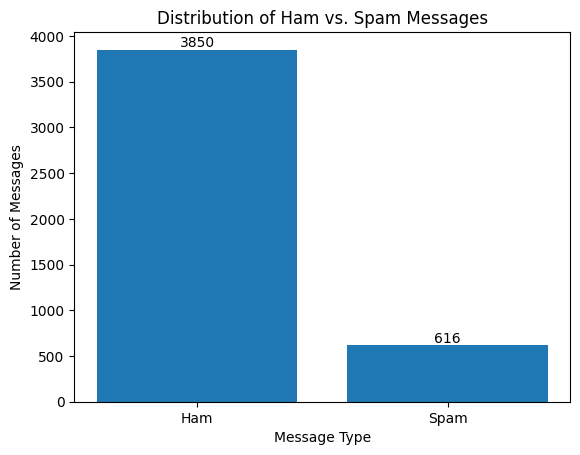

In [ ]:
# Plotting the difference between the number of 'ham' and 'spam' messages
import matplotlib.pyplot as plt

spam_messages = sms_train.filter(sms_train.label_ == 1)
ham_messages = sms_train.filter(sms_train.label_ == 0)

heights = [ham_messages.count(), spam_messages.count()]
bars = plt.bar(x = ['Ham', 'Spam'], height = heights)

# Add labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, yval, ha='center', va='bottom') # +0.05 to place text slightly above the bar

plt.title('Distribution of Ham vs. Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

We can clearly see that the number of 'ham' messages is so much more than that of 'spam' messages.

This imbalance may lead to some issues when running machine learning models on this dataset, such as overfitting.

---



Next we can examine the lengths of text to better understand how long are messages on average.

In [ ]:
from pyspark.sql.functions import length

sms_train = sms_train.withColumn('message_length', length(sms_train.message))

In [ ]:
sms_train.show(10)

+--------------------+------+--------------+
|             message|label_|message_length|
+--------------------+------+--------------+
| &lt;#&gt;  in mc...|     0|            36|
| &lt;#&gt;  mins ...|     0|            51|
| and  picking the...|     0|            41|
| came to look at ...|     0|           103|
| gonna let me kno...|     0|            95|
| says that he's q...|     0|           200|
| what number do u...|     0|            36|
|"7 wonders in My ...|     0|           156|
|"7 wonders in My ...|     0|           156|
|"A Boy loved a ga...|     0|           455|
+--------------------+------+--------------+
only showing top 10 rows


We can visualize the distribution to get a better understanding of the lengths

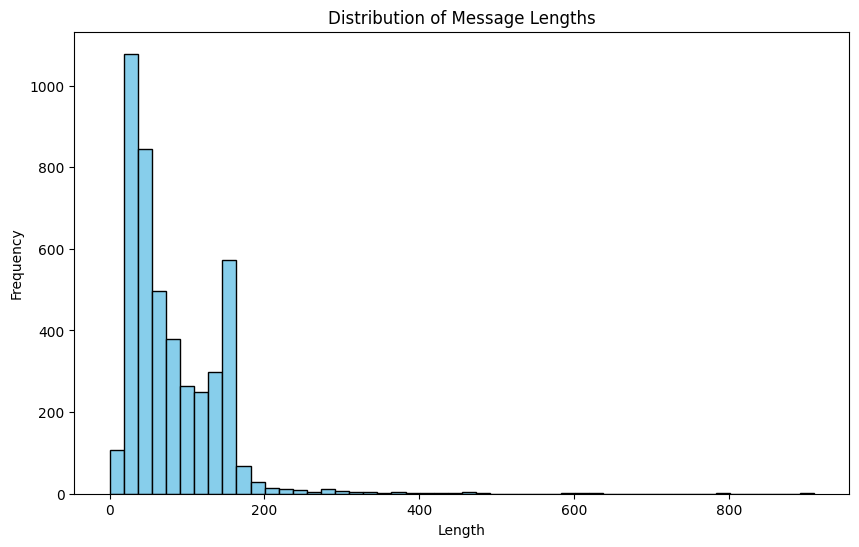

In [ ]:
# Convert the message_length column to a pandas series for plotting
lengths = sms_train.select('message_length').toPandas()

plt.figure(figsize=(10, 6))
plt.hist(lengths['message_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Message Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

Most messages are under 200 characters, which is typical for text messages.

Let's understand more about the messages which are longer than that.

In [ ]:
long_messages = sms_train.filter(sms_train.message_length >= 200)

In [ ]:
long_messages.count()

87

In [ ]:
long_messages.show(10, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+--------------+
|message                                                                                                                                                                                                                                                                                                                                           

In [ ]:
# How many of the long messages are spam?
print(long_messages.filter(long_messages.label_ == 1).count())

# Let's take a look at the message
long_messages.filter(long_messages.label_ == 1).show(truncate=False)

0
+-------+------+--------------+
|message|label_|message_length|
+-------+------+--------------+
+-------+------+--------------+



Only one message that's longer than 200 characters is spam, which begs the question: **Is there a relation between a message's length and it's classification?**

To answer this question, we can use a metric called **Point-Biserial correlation coefficient**, which is used to measure correlation between a continous variable (message_length) and a binary one (label).

It's effictively the same as the **Pearson coefficient**, but the values of one of the variables is restricted to only two values: 0 and 1.

Since the algorithm depends on the mean, it'll be affected heavily by the presence of outliers. So to avoid that, we'll use **Log Transformation** to fit the messages' lengths to a well balanced bell curve.

In [ ]:
from pyspark.sql.functions import log1p, col
sms_train = sms_train.withColumn('length_log', log1p(col('message_length')))

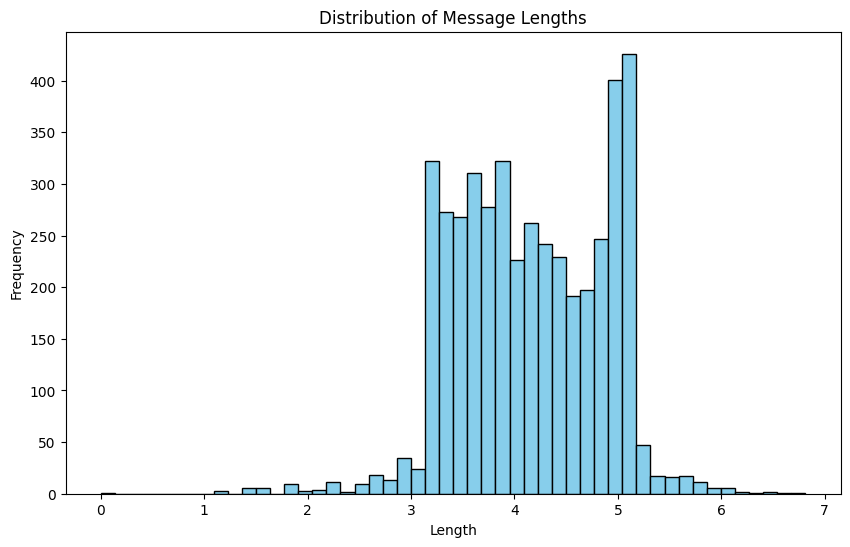

In [ ]:
# Convert the length_log column to a pandas series for plotting
lengths_log = sms_train.select('length_log').toPandas()

plt.figure(figsize=(10, 6))
plt.hist(lengths_log['length_log'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Message Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

Much better. Now we can calculate the metric $r$

In [ ]:
label_length_corr = sms_train.stat.corr('length_log', 'label_', method='pearson')

print(f"Correlation between message label and length: {label_length_corr}")

Correlation between message label and length: 0.41921474689039245


**Interpretation of Correlation**

The Pearson correlation coefficient of approximately **0.402** indicates a moderate **positive correlation**.

In our encoding:
- **0**: Ham (Not Spam)
- **1**: Spam

Because the correlation is positive, an increase in message length is associated with an increase in the label value (moving from 0 to 1). This means that, statistically, **longer messages in this dataset are more likely to be classified as Spam**.

# Feature engineering

We want to train a model that could classify whether a message is spam or not. It does that based on:
1. The words in the message (excluding stop words)
2. The messages's length
3. Both

Also there was the problem of class imbalance. There are two ways we could solve this problem:
- Oversample the 'spam' class, and treat them both as equals
- Assign different weights the classes during training, so the model learns to penalize mistakes in the small class more.

We could try all the different methods, then compare the results.

### Class imbalance

There are two main ways to deal with class imabalance:
- **Oversampling** the small variable
- **Undersampling** the big one

In our case, since we don't have a huge amount of rows, it's best to oversample the 'spam' class. We do that by resampling the 'spam_train' dataframe with replacement.

In [ ]:
# Calculate the ratio needed for oversampling
ratio = int(ham_count / spam_count)

# Filter for spam messages
spam_train = sms_train.filter(col("label_") == 1)
ham_train = sms_train.filter(col("label_") == 0)

# Oversample the spam messages
# We sample with replacement to increase the count
oversampled_spam = spam_train.sample(withReplacement=True, fraction=float(ratio), seed=42)

# Combine back with the ham messages
sms_train_balanced = ham_train.unionAll(oversampled_spam)

# Verify the new distribution
new_ham_count = sms_train_balanced.filter(col("label_") == 0).count()
new_spam_count = sms_train_balanced.filter(col("label_") == 1).count()

print(f"Balanced Ham count: {new_ham_count}")
print(f"Balanced Spam count: {new_spam_count}")

Balanced Ham count: 3850
Balanced Spam count: 3717


### TF-IDF matrix

To feed text data into most models, we must first convert the raw strings into numerical feature vectors. We accomplish this using a PySpark MLlib pipeline consisting of four stages:

1. **Tokenization (`RegexTokenizer`):** Splits the raw message text into individual words (tokens) while stripping out punctuation and special characters using a regular expression.
2. **Stop Words Removal (`StopWordsRemover`):** Filters out highly common, low-information words (e.g., "the", "and", "is") to reduce the dimensionality of the data and remove noise.
3. **Term Frequency (`CountVectorizer`):** Counts the frequency of each remaining word in a message, converting the text into a sparse vector of token counts based on a predefined vocabulary size.
4. **Inverse Document Frequency (`IDF`):** Scales the token counts by evaluating how rare a word is across the entire dataset. This increases the weight of highly specific, predictive terms (which are crucial for spotting spam) while penalizing ubiquitous terms.

In [ ]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline
# 1. Tokenization: Extract words, ignoring punctuation
# pattern="\\W" means it will split on any non-word character.
tokenizer = RegexTokenizer(
    inputCol="message",
    outputCol="words",
    pattern="\\W"
)

# 2. Stop Words Removal: Uses Spark's default English stop words list
remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

# 3. Term Frequency (TF): Create the vocabulary and count term frequencies
# You can adjust vocabSize and minDF (minimum document frequency) to tune performance
cv = CountVectorizer(
    inputCol="filtered_words",
    outputCol="raw_features",
    vocabSize=10000,
    minDF=5.0
)

# 4. Inverse Document Frequency (IDF): Scale the features
idf = IDF(
    inputCol="raw_features",
    outputCol="tfidf_features"
)

# 5. Assemble the Pipeline
# (You would append your LogisticRegression model to the end of this list later)
nlp_pipeline = Pipeline(stages=[tokenizer, remover, cv, idf])

# --- Execution ---

# Fit the pipeline on the training data (this learns the vocabulary and IDF weights)
tfidf_model = nlp_pipeline.fit(sms_train_balanced)

# Transform the training data
train_tfidf_df = tfidf_model.transform(sms_train_balanced)

# Show the results
train_tfidf_df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------+------+--------------+------------------+-----------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|message                                                                                                |label_|message_length|length_log        |words                                                                                                           

## Model Training

In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier

In [ ]:
# LogisticRegression model
lr = LogisticRegression(featuresCol="tfidf_features", labelCol="label_", maxIter=20)
lr_model = lr.fit(train_tfidf_df)

In [ ]:
# Decision tree model

In [ ]:
# Random forest model

## Pipeline Construction

Now we combine all the preprocessing and preparation steps in one pipeline, so that every new data goes through the same steps before predictions.

In [ ]:
def lr_pipeline(df):
    # FIRST STEP
    # Concatenate v2 and the extra columns into a single 'message' column
    if df.columns != ['label', 'message']:
      # concat_ws ignores null values automatically
      df = df.withColumn('message', concat_ws(' ', col('v2'), col('_c2'), col('_c3'), col('_c4')))

      # Select only the label (v1) and the new message column and rename 'v1' to 'label'
      df = df.select(col('v1').alias('label'), 'message')

    # SECOND STEP
    # Map label column to numerical value
    # Map 'spam' to 1 and 'ham' to 0
    df = df.withColumn('label_', when(df.label == 'spam', 1.0).otherwise(0.0))

    # We no longer need the string 'label' column
    df = df.drop('label')

    # THIRD STEP
    # Create the tfidf matrix, and return the model to use it for the test data
    tfidf_df = tfidf_model.transform(df)

    # FOURTH STEP
    # Test the logistic regression model
    lr_results = lr_model.transform(tfidf_df)

    return tfidf_df, lr_results

In [ ]:
def test_pipeline(df):
    # FIRST STEP: Generalize concatenation
    # Combine all existing columns into one 'message' column to handle any input schema
    input_cols = df.columns

    if len(input_cols) > 1:
        # concat_ws ignores null values automatically
        df = df.withColumn('message', concat_ws(' ', *[col(c) for c in input_cols]))
    elif len(input_cols) == 1 and input_cols[0] != 'message':
        df = df.withColumnRenamed(input_cols[0], 'message')

    # Ensure we only proceed with the single message column
    df = df.select('message')

    # SECOND STEP
    # Create the tfidf matrix using the pre-trained nlp_pipeline/tfidf_model
    tfidf_df = tfidf_model.transform(df)

    # THIRD STEP
    # Apply the pre-trained logistic regression model
    lr_results = lr_model.transform(tfidf_df)

    return tfidf_df, lr_results

In [ ]:
test_tfidf_df, lr_test = lr_pipeline(sms_test)

In [ ]:
test_tfidf_df.show(5)

+--------------------+------+--------------------+--------------------+--------------------+--------------------+
|             message|label_|               words|      filtered_words|        raw_features|      tfidf_features|
+--------------------+------+--------------------+--------------------+--------------------+--------------------+
| &lt;DECIMAL&gt; ...|   0.0|[lt, decimal, gt,...|[lt, decimal, gt,...|(2935,[17,49,50,5...|(2935,[17,49,50,5...|
| said kiss, kiss,...|   0.0|[said, kiss, kiss...|[said, kiss, kiss...|(2935,[37,248,447...|(2935,[37,248,447...|
|"7 wonders in My ...|   0.0|[7, wonders, in, ...|[7, wonders, worl...|(2935,[4,46,57,10...|(2935,[4,46,57,10...|
|"7 wonders in My ...|   0.0|[7, wonders, in, ...|[7, wonders, worl...|(2935,[4,46,57,10...|(2935,[4,46,57,10...|
|"A Boy loved a ga...|   0.0|[a, boy, loved, a...|[boy, loved, gal,...|(2935,[1,2,3,43,4...|(2935,[1,2,3,43,4...|
+--------------------+------+--------------------+--------------------+-----------------

In [ ]:
lr_test.show()

+--------------------+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
|             message|label_|               words|      filtered_words|        raw_features|      tfidf_features|       rawPrediction|         probability|prediction|
+--------------------+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
| &lt;DECIMAL&gt; ...|   0.0|[lt, decimal, gt,...|[lt, decimal, gt,...|(2935,[17,49,50,5...|(2935,[17,49,50,5...|[37.1090250093559...|           [1.0,0.0]|       0.0|
| said kiss, kiss,...|   0.0|[said, kiss, kiss...|[said, kiss, kiss...|(2935,[37,248,447...|(2935,[37,248,447...|[49.9391425184937...|           [1.0,0.0]|       0.0|
|"7 wonders in My ...|   0.0|[7, wonders, in, ...|[7, wonders, worl...|(2935,[4,46,57,10...|(2935,[4,46,57,10...|[69.2400398349608...|           [1.0,0.0]|       0.0

In [ ]:
# Rows that the model got wrong
lr_test.filter(col('label_') != col('prediction')).show(truncate = False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Phase 7: Model Evaluation

In [ ]:
from pyspark.sql.functions import col, when
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Make predictions using the pipeline model
test_tfidf_df, predictions = lr_pipeline(sms_test)

# Evaluate Logistic Regression
evaluator_lr = MulticlassClassificationEvaluator(labelCol="label_", predictionCol="prediction", metricName="f1")
acc_lr = evaluator_lr.evaluate(predictions)

print(f"Logistic Regression F1-score: {acc_lr:.4f}")

Logistic Regression F1-score: 0.9744


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Define the evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label_", predictionCol="prediction")

# Calculate metrics
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Print metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9747
Precision: 0.9743
Recall:    0.9747
F1 Score:  0.9744


## Phase 9: Model Saving & Loading

In [ ]:
from pyspark.ml import Pipeline, PipelineModel
import os
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression

# Assuming tokenizer, remover, cv, idf, and lr are defined in previous cells
# Create the full end-to-end pipeline with all feature engineering steps and the classifier
# Note: 'lr' here refers to the LogisticRegression estimator, not the fitted model 'lr_model'
full_pipeline_with_lr = Pipeline(stages=[tokenizer, remover, cv, idf, lr])

# Fit this full pipeline to the balanced training data
# This will train all feature transformers and the logistic regression model together
full_pipeline_model = full_pipeline_with_lr.fit(sms_train_balanced)

# Save the trained complete pipeline model
model_path = "spam_detection_pipeline_model"
full_pipeline_model.write().overwrite().save(model_path)
print(f"Model saved to {model_path}")

# Reload the model
loaded_model = PipelineModel.load(model_path)
print("Model loaded successfully")

AttributeError: 'function' object has no attribute 'write'

## Phase 10: Prediction on New Data

In [ ]:
from pyspark.sql.functions import when

# Test the model using new SMS messages
new_messages = [
    ("Congratulations! You've won a $1000 Walmart gift card. Click here to claim.",),
    ("Hey, are we still meeting for lunch at 12?",),
    ("URGENT! Your mobile number has been selected for a prize. Call 09061701461 to claim.",),
    ("I'll be home in 10 minutes, see you soon.",),
    ("WINNER WINNER CHICKEN DINNER",),
    ("Hello babe, miss you. What time do you finish work? xoxo",)
]
new_data = spark.createDataFrame(new_messages, ["message"])

# Display predictions
tfidf, predictions_new = test_pipeline(new_data)

# Map numeric predictions back to labels for display
predictions_final = predictions_new.withColumn(
    "label_prediction",
    when(col("prediction") == 1.0, "spam").otherwise("ham")
)

predictions_final.select("message", "label_prediction").show(truncate=False)

+------------------------------------------------------------------------------------+----------------+
|message                                                                             |label_prediction|
+------------------------------------------------------------------------------------+----------------+
|Congratulations! You've won a $1000 Walmart gift card. Click here to claim.         |spam            |
|Hey, are we still meeting for lunch at 12?                                          |ham             |
|URGENT! Your mobile number has been selected for a prize. Call 09061701461 to claim.|spam            |
|I'll be home in 10 minutes, see you soon.                                           |ham             |
|WINNER WINNER CHICKEN DINNER                                                        |spam            |
|Hello babe, miss you. What time do you finish work? xoxo                            |ham             |
+---------------------------------------------------------------